# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
from tqdm import tqdm
importlib.reload(up)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

## Set font to helvetica 
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Helvetica']


In [ ]:
# outfig_dest = Path('CCN_2024/figures')
# outfig_dest.mkdir(parents=True, exist_ok=True)





### Import human data

In [3]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_all_conds/data/*.json"))

len(human_fnames)

428

## Process Human Results

In [4]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
## Filter self reported hearing loss 
results_df = results_df[results_df.hearing_loss == False]
# results_df = results_df[results_df.over_ear_hf == True]

## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_attn_expmt_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_snr_and_cond(x, stim_cond_map=stim_cond_map)))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()
trial_results.rename(columns={"condition":"raw_condition"}, inplace=True)

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}
# 1-talker conds preserved in replace below

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 196
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 84194 (char 84193)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6658b1491e88ec15902d5301.json
Unterminated string starting at: line 1 column 192613 (char 192612)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6174b049932ee98236563b51.json
Unterminated string starting at: line 1 column 72207 (char 72206)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_65dc99d0191a135ab835bf69.json
Unterminated string starting at: line 1 column 324626 (char 324625)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_5c0430c71a20110001e9b05a.json
Expecting ',' delimiter: line 1 column 204794 (char 204793)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_666883e7cd549b6798159085.json
Unterminated string starting at: line 1 column 60213

In [5]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  208
N good participants  195



#### Add re-scored performance based on entries included in excerpt transcripts  

In [ ]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



### Manage in-transcript rescoring

In [7]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'gender',
                 'word',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"
]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.same_sex_dist_1_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
same_sex_distractor_words = analysis_df.same_sex_dist_1_word.values
diff_sex_distractor_words = analysis_df.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = analysis_df.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = analysis_df.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

## Remap 1-talker distractor names accordingly 

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'sex_cond'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-1].str.title()
analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'dist_lang'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-2].str.title()

def remap_1_distractor_str(cond_str):
    if 'english' in cond_str:
        return '1-talker'
    if 'mandarin' in cond_str:
        return "Mandarin distractor"
    if 'dutch' in cond_str:
        return "Dutch distractor"

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].apply(remap_1_distractor_str)
analysis_df = analysis_df[analysis_df.condition != 'catch_trial']



/tmp/ipykernel_2004636/1357835774.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)


In [8]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [ ]:
analysis_df.condition.unique()

array(['stationary', 'Mandarin distractor', 'natural scene', 'clean',
       'Dutch distractor', '1-talker', 'babble', '2-talker', '4-talker',
       'music'], dtype=object)

In [10]:
##########################
# Make df for f0 analysis 
##########################

# drop unwanted conditions
f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'Mandarin distractor', 'clean'])].copy()

# cut and remove language-specific f0 columns - just make distractor f0 
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'english_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
# f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values

f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
def get_f0_ratio(row):
    return max(row.target_f0, row.distractor_f0) / min(row.target_f0, row.distractor_f0)
f0_analysis_df["f0_ratio"] = f0_analysis_df.apply(get_f0_ratio, axis=1)

# # rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
cols_to_drop = [col for col in f0_analysis_df.columns if 'trial' in col ]
# drop prolific meta columns
f0_analysis_df = f0_analysis_df.drop(columns=cols_to_drop).reset_index(drop=True)


In [11]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


/tmp/ipykernel_2004636/1142350907.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)


In [ ]:
## Summarize participant data for aggregate plotting

summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


## Load Model Results 

In [ ]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
cond_map = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_cond_map.pkl", "rb" )) 
conds = set([cond for cond,snr in cond_map.values()])

test_cond_to_human = {v:k for k,v in test_condition_dict.items()}
cond_remap = {}
for cond in conds:
    if cond in test_cond_to_human:
        cond_remap[cond] = test_cond_to_human[cond]
    else:
        cond_remap[cond] = cond 
cond_remap['natural scene'] = 'natural scene'


In [ ]:
cond_remap

{'4-talker': '4-talker',
 '1-talker-dutch-same': '1-talker-dutch-same',
 'background_issnstationary': 'stationary',
 'background_ieeeaaspcasa': 'natural scene',
 '2-talker': '2-talker',
 '1-talker-english-different': '1-talker-english-different',
 'background_musdb18hq': 'music',
 '1-talker-mandarin-same': '1-talker-mandarin-same',
 '1-talker-mandarin-different': '1-talker-mandarin-different',
 'SILENCE': 'clean',
 '1-talker-english-same': '1-talker-english-same',
 '1-talker-dutch-different': '1-talker-dutch-different',
 'background_cv08talkerbabble': 'babble',
 'natural scene': 'natural scene'}

In [ ]:

model_names = [
    # "word_task_half_co_loc_v10_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout",
                # "word_task_v08_control_no_attn",
                "word_task_v10_control_no_attn",
                "word_task_early_only_v10",
                "word_task_late_only_v10",
                # "word_task_half_co_loc_v10_50Hz_cutoff",
                "word_task_v10_main_feature_gain_config"
                # "word_task_conventional_layer_order"
                ]# "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"]
             
arch_search_models = [path.stem for path in Path('swc_2024_eval_full_stim/').glob('*v10*arch_*')]
model_names.extend(arch_search_models)


model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   'word_task_v10_control_no_attn': 'Baseline CNN',
                   'word_task_early_only_v10': 'Early-only',
                   'word_task_late_only_v10': 'Late-only',


                   "word_task_v10_main_feature_gain_config": 'Feature-gain Model',
                  }

all_model_results = []
all_model_f0_results = []

background_conditions = summary_df.background_condition.unique() 
str_to_cond = {v:k for k,v in test_condition_dict.items()}

## preselect manifest columns 
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"

]

manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index

# update gt manifests to match readable format 
for model_name in model_names:
    print(model_name)
    output_paths = list(Path(f'swc_2024_eval_full_stim/{model_name}').glob('*.csv'))
    print(len(output_paths))
    results_dfs = []

    for path in output_paths:
        # print(path)
        try:
            df = pd.read_csv(path)
            # reformat dict
            df['model'] = path.parent.name
            #parts of name 
            parts = path.stem.split(path.parent.name)[-1].split('_')   
            # if 'stim_tag' in df.columns:
            #     # rename 
            #     df.rename(columns={'stim_tag':'stim_name'}, inplace=True)
            # use re to split path.stem after model name and before <int>dB 
            df['background_condition'] = [v for v in cond_remap.values() if "_".join(v.split(' ')) in path.stem][0]
            if 'clean' in path.stem:
                df['background_condition'] = 'clean'
                df['snr'] =  'inf' # really np.inf, 6 for plotting 
            else:
                df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))

            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])

            results_dfs.append(df)
        except Exception as e:
            # print(e)
            continue


    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    if model_name in model_name_dict:
        model_str = model_name_dict[model_name]
    else:
        model_str = model_name
    model_results['group'] = model_str
    ## Load in model vocab 
    model_results['pred_word'] = model_results['pred_word_int'].replace(cv_class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(cv_class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'sex_cond'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-1].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'dist_lang'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-2].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].apply(remap_1_distractor_str)

    
    all_model_results.append(model_results)


    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'Mandarin distractor', 'clean'])].copy()
    model_f0_df.loc[model_f0_df.dist_lang == 'English', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'English', 'english_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
    # model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    model_f0_df["f0_ratio"] = model_f0_df.apply(get_f0_ratio, axis=1)
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

/tmp/ipykernel_2004636/1567140680.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifests['word_int'] = manifests.word.replace(cv_word_2_class)


word_task_v10_control_no_attn
61
word_task_early_only_v10
61
word_task_late_only_v10
61
word_task_v10_main_feature_gain_config
61
word_task_v10_4MGB_ln_first_arch_1
61
word_task_v10_4MGB_ln_first_arch_10
61
word_task_v10_4MGB_ln_first_arch_12
61
word_task_v10_4MGB_ln_first_arch_2
61
word_task_v10_4MGB_ln_first_arch_4
61
word_task_v10_4MGB_ln_first_arch_6
61
word_task_v10_4MGB_ln_first_arch_7
61
word_task_v10_4MGB_ln_first_arch_8
61
word_task_v10_4MGB_ln_first_arch_9
61


## Summarize data for analysis and plotting

In [ ]:
# Adjusted accuracy should always greater than or equal to accuracy
(all_model_results['adjusted_accuracy'] >= all_model_results['accuracy']).all() 

True

### Summarize main experiment

In [17]:
N = int(summary_df.N.unique().item())

summary_df['group'] = f'Humans (N={N})'
model_results['group'] = model_results['group']
# all_model_results = all_model_results[all_model_results.snr > -12]
# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, all_model_results], axis=0, ignore_index=True)

combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')

combined_results['background_condition'].rename({"stationary":"noise"}, inplace=True)
# combined_results = combined_results[combined_results.snr > -12]
combined_results.loc[combined_results.background_condition == "stationary", 'background_condition'] = "noise"
combined_results.loc[combined_results.group.str.contains('Human'), 'model'] = combined_results.loc[combined_results.group.str.contains('Human'), 'group'] 


### Summarize distractor sex and language results

In [ ]:
def bootstrap_sem(data, n_bootstraps=10000):
    bootstrapped_means = np.zeros(n_bootstraps)
    n = len(data)
    for i in range(n_bootstraps):
        bootstrapped_sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_means[i] = bootstrapped_sample.mean()
    return bootstrapped_means.std()


In [150]:
#################################
# Summarize human and fba model 
#################################

f0_analysis_df['group'] =  f'Humans (N={N})'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'sex_cond'] = 'clean'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'dist_lang'] = 'None'
f0_analysis_df.reset_index(inplace=True, drop=True)

all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'sex_cond'] = 'Clean'
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'dist_lang'] = 'None'

model_f0_results = all_model_f0_results[~all_model_f0_results.group.str.contains('Baseline|Early|Late')].copy()

dfs = {}
conds = ['sex_cond', 'dist_lang']
groups = [f'Humans (N={N})', 'Feature-gain Model']
part_level_summary = {}
for group in groups:
    dfs[group] = {}
    part_level_summary[group] = {}
    if group == f'Humans (N={N})':
        part_tag = "id_subject"
        df = f0_analysis_df
    elif group == 'Feature-gain Model':
        part_tag = 'model'
        df = model_f0_results
    for cond in conds:
        if cond == 'sex_cond':
            df_to_run = df[df.dist_lang == 'English'].copy()
        else:
            df_to_run = df.copy()
        summary_df = (df_to_run.groupby([part_tag, "snr", cond]) # average over language 
                        .agg({
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                        .reset_index())
        summary_df['snr'] = summary_df['snr'].replace(np.inf, 6)
        summary_df['snr'] =  summary_df['snr'].replace("inf", 6)
        summary_df['snr'] = summary_df['snr'].astype('int')
        # flatten multiindex 
        summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
        # remove trailing underscore
        summary_df.columns = [col[:-1] if col.endswith('_') else col for col in summary_df.columns.values]
        summary_df.columns = [part_tag, 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']

        part_level_summary[group][cond] = summary_df

        # aggregate over participants/model architectures
        df_to_keep = summary_df.groupby(['snr', 'background_condition']).agg({
                            'accuracy':['mean','sem'], 'confusions':['mean', 'sem', 'count']}).reset_index()
        
        df_to_keep.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']
        df_to_keep['group'] = group
        dfs[group][cond] = df_to_keep


human_sex_lang_summary = pd.concat(dfs[f'Humans (N={N})'].values(), axis=0, ignore_index=True)
human_sex_lang_summary = human_sex_lang_summary[human_sex_lang_summary.background_condition != 'None']

fba_totaL_sex_lang_summary = pd.concat(dfs['Feature-gain Model'].values(), axis=0, ignore_index=True)
fba_totaL_sex_lang_summary = fba_totaL_sex_lang_summary[fba_totaL_sex_lang_summary.background_condition != 'None']

# save individual model results for stats / null distributions 
fba_model_sex_lang_summary = pd.concat(part_level_summary['Feature-gain Model'].values(), axis=0, ignore_index=True)
fba_model_sex_lang_summary = fba_model_sex_lang_summary[fba_model_sex_lang_summary.background_condition != 'None']

human_sex_lang_summary = pd.concat(part_level_summary[f'Humans (N={N})'].values(), axis=0, ignore_index=True)
human_sex_lang_summary = human_sex_lang_summary[human_sex_lang_summary.background_condition != 'None']

############################
# Summarize control models
############################

model_f0_results = all_model_f0_results[all_model_f0_results.group.str.contains('Baseline|Early|Late')].copy()
control_summary = []
for cond in conds:
    if cond == 'sex_cond':
        df = model_f0_results[model_f0_results.dist_lang == 'English']
    else:
        df = model_f0_results
    for (model, snr, condition), group in df.groupby(['model', 'snr', cond]):
        accs = group.adjusted_accuracy.values
        confs = group.adjusted_confusions.values
        acc_sem = bootstrap_sem(accs)
        conf_sem = bootstrap_sem(confs)
        if 'early' in model:
            group = 'Early-only model'
        elif 'late' in model:
            group = 'Late-only model'
        elif 'control' in model:
            group = 'Baseline model'
        control_summary.append(
                                {'group':group, 'model':model, 'snr': snr, 'background_condition': condition, 
                                'accuracy': accs.mean(), 'acc_sem': acc_sem,
                                'confusions': confs.mean(), 'conf_sem': conf_sem, 'N':1}
                )
control_sex_lang_summary = pd.DataFrame(control_summary)
control_sex_lang_summary = control_sex_lang_summary[control_sex_lang_summary.background_condition != 'None'].reset_index(drop=True)

/tmp/ipykernel_2004636/3730572929.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary_df['snr'] =  summary_df['snr'].replace("inf", 6)
/tmp/ipykernel_2004636/3730572929.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary_df['snr'] =  summary_df['snr'].replace("inf", 6)


In [152]:
human_sex_lang_summary

,id_subject,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,N
0,559272f4fdf99b7e42e96932,-9,Different,0.50,0.500000,0.0,0.0,2
1,559272f4fdf99b7e42e96932,-9,Same,0.00,0.000000,0.0,0.0,2
2,559272f4fdf99b7e42e96932,-6,Different,0.50,0.500000,0.5,0.5,2
3,559272f4fdf99b7e42e96932,-6,Same,1.00,0.000000,0.0,0.0,2
4,559272f4fdf99b7e42e96932,-3,Different,0.00,0.000000,0.0,0.0,2
...,...,...,...,...,...,...,...,...
4089,668bb6a70c92907a25c9895f,-3,Mandarin,0.75,0.250000,0.0,0.0,4
4090,668bb6a70c92907a25c9895f,0,English,0.50,0.288675,0.0,0.0,4
4091,668bb6a70c92907a25c9895f,0,Mandarin,0.50,0.288675,0.0,0.0,4
4092,668bb6a70c92907a25c9895f,3,English,0.75,0.250000,0.0,0.0,4


In [ ]:
##########################
# set common column names 
##########################
full_df_col_names = ['model', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']
summary_df_col_names = ['group', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']

# screen language results - will use what we summarized above
combined_results = combined_results[~combined_results.background_condition.str.contains('Mandarin|Dutch')]

##########################
# Get human data summary
##########################
human_summary = combined_results[combined_results.group.str.contains('Human')].copy()
human_summary = human_summary[['group', 'snr', 'background_condition', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']]
# human_summary['model'] = human_summary['group']
human_summary.columns = summary_df_col_names
human_summary = pd.concat([human_summary, human_sex_lang_summary], axis=0, ignore_index=True)

# make human_part level summary 
part_summary_to_keep = part_summary_df[['snr', 'id_subject', 'condition', 'adjusted_accuracy_mean', 'adjusted_confusions_mean']]
part_summary_to_keep.columns = ['snr', 'id_subject', 'background_condition', 'accuracy', 'confusions']
participant_level_sumary = pd.concat([part_summary_to_keep, human_sex_lang_summary], axis=0, ignore_index=True)

#################################
# Get feature-gain model summary
#################################
fba_data = combined_results[combined_results.group.str.contains('Feature|_arch_')].copy()
fba_model_summary = fba_data.groupby(['model', 'snr', 'background_condition']).agg({'adjusted_accuracy':['mean', 'sem'], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
fba_model_summary.columns = full_df_col_names
# combine with sex and language result

fba_total_summary = fba_model_summary.groupby(['snr', 'background_condition']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem', 'count']}).reset_index()
fba_total_summary.columns = summary_df_col_names[1:]
fba_total_summary['group'] = 'Feature-gain Model'
fba_total_summary = fba_total_summary[summary_df_col_names]
# combine with sex and language result
fba_model_summary = pd.concat([fba_model_summary, fba_model_sex_lang_summary], axis=0, ignore_index=True)
fba_total_summary = pd.concat([fba_total_summary, fba_totaL_sex_lang_summary], axis=0, ignore_index=True)

#############################
# Get control model summary
#############################
control_models = combined_results[combined_results.model.str.contains('early|late|control')].copy()
control_summary = []
for (model, snr, condition), group in control_models.groupby(['model', 'snr', 'background_condition']):
    accs = group.adjusted_accuracy.values
    confs = group.adjusted_confusions.values
    acc_sem = bootstrap_sem(accs)
    conf_sem = bootstrap_sem(confs)
    if 'early' in model:
        group = 'Early-only model'
    elif 'late' in model:
        group = 'Late-only model'
    elif 'control' in model:
        group = 'Baseline model'
    control_summary.append(
                            {'group':group, 'model':model, 'snr': snr, 'background_condition': condition, 
                             'accuracy': accs.mean(), 'acc_sem': acc_sem,
                             'confusions': confs.mean(), 'conf_sem': conf_sem, 'N':1}
              )
control_summary = pd.DataFrame(control_summary)
# merge and drop duplicate clean row from distractor language analysis 
control_summary = pd.concat([control_summary, control_sex_lang_summary], axis=0, ignore_index=True)  

In [140]:
### Set up plot df 
human_summary['model'] = human_summary['group']
fba_total_summary['model'] = fba_total_summary['group']
all_combined = pd.concat([human_summary, fba_model_summary, control_summary], axis=0, ignore_index=True)
df_to_plot = pd.concat([human_summary, fba_total_summary, control_summary], axis=0, ignore_index=True)
df_to_plot['snr'] = df_to_plot['snr'].astype('int')
all_combined['snr'] = all_combined['snr'].astype('int')

## Standard analysis 

##### Look at all models individually

In [141]:
all_combined[all_combined.background_condition == 'clean'].groupby('model').accuracy.mean().sort_values()

model
word_task_v10_control_no_attn             0.793033
word_task_v10_4MGB_ln_first_arch_4        0.806352
word_task_early_only_v10                  0.811475
word_task_v10_4MGB_ln_first_arch_9        0.815574
word_task_late_only_v10                   0.816598
word_task_v10_4MGB_ln_first_arch_12       0.817623
word_task_v10_4MGB_ln_first_arch_6        0.822746
word_task_v10_4MGB_ln_first_arch_1        0.838115
word_task_v10_4MGB_ln_first_arch_10       0.843238
word_task_v10_4MGB_ln_first_arch_2        0.848361
word_task_v10_4MGB_ln_first_arch_8        0.850410
word_task_v10_main_feature_gain_config    0.853484
word_task_v10_4MGB_ln_first_arch_7        0.858607
Humans (N=195)                            0.880769
Name: accuracy, dtype: float64

In [142]:
df_to_plot.snr.unique()

array([-9, -6, -3,  0,  3,  6])

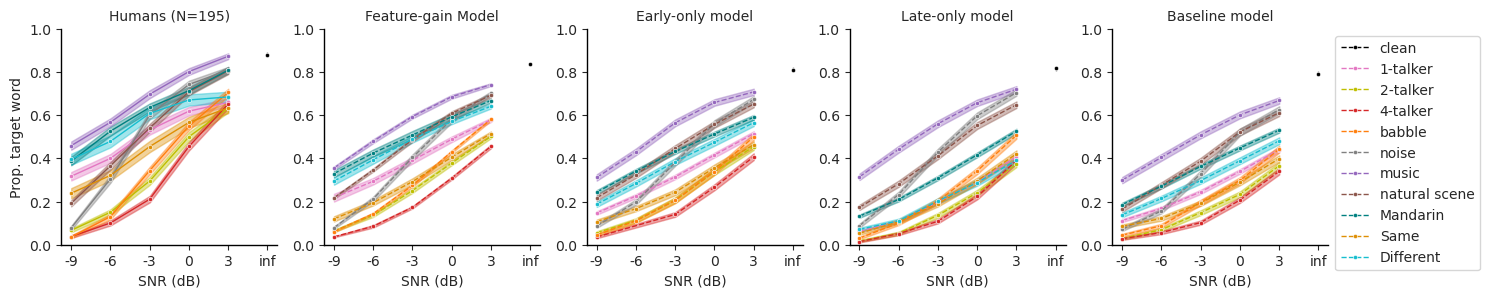

In [143]:
# df_to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
# df_to_plot = combined_results[(~combined_results.background_condition.isin(["catch_trial", 'audioset']))  ] # & ~(combined_results.group == 'Baseline CNN')
sns.set_style('ticks')



# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'noise',  'music', 'natural scene',  'Mandarin', "Same", "Different"]
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
palette['Mandarin'] = 'teal'

sex_order = ['Different', 'Same', 'clean']

sex_pal = dict(zip(sex_order[:-1], sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Different'] = 'tab:cyan'
palette['Same'] = sex_pal['Same']

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = df_to_plot.group.unique()

aspect = 3
sem_order = 1 
n_models = len(models)
n_rows = 1
n_cols = n_models 

fig, axs = plt.subplots(n_rows, n_cols, figsize=((aspect) * n_cols , aspect * n_rows))
axs = axs.flatten()
err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', ]
x_tick_locs = df_to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=df_to_plot[df_to_plot.group == model],  x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                #   errorbar=('se', 2), err_style='band',
                #     err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = df_to_plot[df_to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        error = selected['acc_sem'].values * sem_order
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'].values, selected['accuracy'].values - error,
                         selected['accuracy'].values + error, color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
for ix in range(n_models-1):
    axs[ix].legend().remove()
for ix in range(1,len(axs)):
    axs[ix].set_ylabel("", fontsize=fontsize)

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# set space between pannels 
# plt.subplots_adjust(wspace=0.25)
# 
plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_acc_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

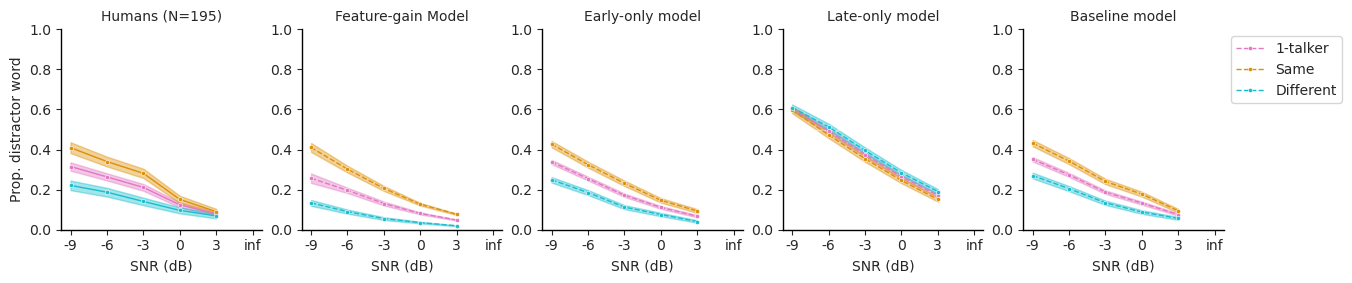

In [147]:
# df_to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
sns.set_style('ticks')

# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['1-talker', "Same", "Different"]

# palette['Mandarin distractor'] = 'teal'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = df_to_plot.group.unique()

aspect = 3
sem_order = 1 
n_models = len(models)
n_rows = 1
n_cols = n_models 

fig, axs = plt.subplots(n_rows, n_cols, figsize=((aspect) * n_cols , aspect * n_rows))
axs = axs.flatten()
err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', ]
x_tick_locs = df_to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    ax.plot(x_tick_locs, np.ones(len(x_tick_locs)) * 0.5, 'w', alpha=0.5, label=None)
    data = df_to_plot[df_to_plot['group'].eq(model)]
    sns.lineplot(data=data,  x='snr', y='confusions', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=None,# err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        error = selected['conf_sem'] * sem_order
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['confusions'] - error,
                         selected['confusions'] + error, color=palette[group], alpha=err_band_alpha)

            
    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()

for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# set space between pannels 
# plt.subplots_adjust(wspace=0.25)

# plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_conf_english_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

In [ ]:
### Run stats on human results 
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm


to_anova = participant_level_sumary[participant_level_sumary.background_condition.isin(["Same", "Different"])].copy()

aov = AnovaRM(to_anova, depvar='confusions', subject='id_subject',
    within=["snr", "background_condition"]).fit()
print(aov)

              Anova
    F Value Num DF  Den DF  Pr > F
----------------------------------
snr 51.7079 4.0000 776.0000 0.0000

                         Anova
                         F Value Num DF  Den DF  Pr > F
-------------------------------------------------------
snr                      51.7079 4.0000 776.0000 0.0000
background_condition     89.1077 1.0000 194.0000 0.0000
snr:background_condition  7.8389 4.0000 776.0000 0.0000



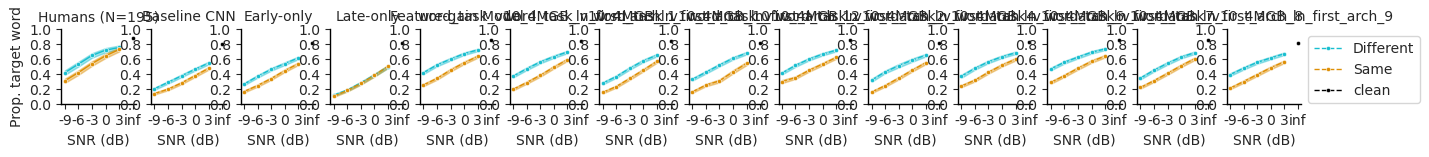

In [64]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_dist_sex_results.copy()
# don't plot baseline 
# to_plot = to_plot[to_plot.group != 'Baseline CNN']
# hue_order = summary_df.sex_cond.unique()
hue_order = ['Different', 'Same', 'clean']

palette = dict(zip(hue_order[:-1], sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['clean'] = 'k'
palette['Different'] = 'tab:cyan'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

aspect = 4
n_models = len(models)
fig, axs = plt.subplots(1, n_models, figsize=((aspect) * aspect , aspect ))


err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', "Baseline CNN"]
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='sex_cond', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != f'Humans (N={N})':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# # set space between pannels 
# plt.subplots_adjust(wspace=0.25)

# plt.savefig(outfig_dest/'human_model_save_diff_sex_acc.pdf', transparent=True, bbox_inches='tight')



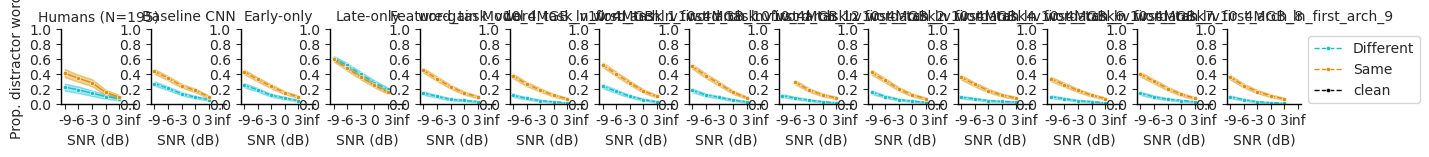

In [65]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = human_dist_df[human_dist_df.dist_lang == 'English']
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

N = int(to_plot.id_subject.nunique())
to_plot = to_plot.groupby(['snr', 'sex_cond']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
to_plot.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


## distractor sex 
to_plot['group'] = f'Humans (N={N})'
combined_dist_sex_results_confs = pd.concat([to_plot, all_model_f0_results[all_model_f0_results.dist_lang == 'English']], axis=0, ignore_index=True)
combined_dist_sex_results_confs.loc[combined_dist_sex_results_confs.snr == np.inf, 'snr'] = 6
combined_dist_sex_results_confs.loc[combined_dist_sex_results_confs.snr == 'inf', 'snr'] = 6
combined_dist_sex_results_confs.snr = combined_dist_sex_results_confs.snr.astype('int')

# don't plot baseline 
# to_plot = combined_dist_sex_results_confs[combined_dist_sex_results_confs.group != 'Baseline CNN']
to_plot = combined_dist_sex_results_confs.copy()

# hue_order = summary_df.sex_cond.unique()
hue_order = ['Different', 'Same', 'clean']

palette = dict(zip(hue_order[:-1], sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['clean'] = 'k'
palette['Different'] = 'tab:cyan'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

aspect = 4
n_models = len(models)
fig, axs = plt.subplots(1, n_models, figsize=((aspect) * aspect , aspect ))

err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', "Baseline CNN"]
# x_tick_locs = to_plot.snr.unique()
# x_tick_locs = np.append(x_tick_locs, [6])
# x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    ax.plot(x_tick_locs, np.ones(len(x_tick_locs)) * 0.5, 'w', alpha=0.5, label=None)
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_confusions', hue='sex_cond', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_confusions'] - selected['adj_conf_std_error'],
                         selected['adjusted_confusions'] + selected['adj_conf_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model !=  f'Humans (N={N})':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
# sns.despine()
# # turn off axs[0] legend 
# axs[0].legend().remove()
# axs[1].legend().remove()
# axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
# axs[1].set_ylabel("", fontsize=fontsize)
# axs[2].set_ylabel("", fontsize=fontsize)
# # move axs[1] legend 
# axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# # set space between pannels 
# plt.subplots_adjust(wspace=0.25)

# plt.savefig(outfig_dest/'human_model_same_diff_sex_confs.pdf', transparent=True, bbox_inches='tight')



In [66]:
data = to_plot[to_plot['group'].eq(model)]
data.background_condition.unique()

array(['1-talker'], dtype=object)

### Plot unfamiliar distractor

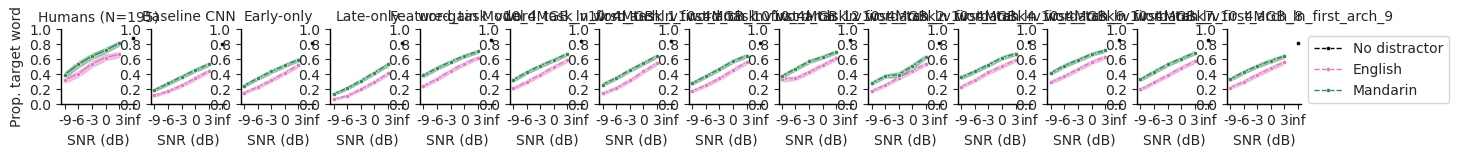

In [67]:
to_plot = combined_dist_lang_results.copy()
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

to_plot.loc[to_plot.dist_lang == 'None', "dist_lang"] = 'No distractor'
to_plot.loc[to_plot.dist_lang.isna(), "dist_lang"] = 'No distractor'

# hue_order = summary_df.dist_lang.unique()
cmap = sns.color_palette("gnuplot2", n_colors=3)

hue_order = ['No distractor','Mandarin' , 'English', 'Dutch',]
hue_plot_order = ['No distractor', 'English', 'Mandarin']
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

palette = {lang:cmap[ix] for ix, lang in enumerate(hue_order[1:])}
palette['No distractor'] = 'k'
palette['English'] = 'tab:pink'
palette['Mandarin'] = 'seagreen'
palette['Dutch'] = 'orange'


fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

aspect = 4
n_models = len(models)
fig, axs = plt.subplots(1, n_models, figsize=((aspect) * aspect , aspect ))


# aspect = 2
# fig, axs = plt.subplots(1, 3, figsize=((aspect) * 3.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', 'Baseline CNN']
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='dist_lang', hue_order=hue_plot_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('dist_lang'):
        if not group in hue_plot_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')


sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)
# set space between pannels 
# plt.subplots_adjust(wspace=0.25)
# plt.savefig(outfig_dest/'human_model_unfamiliar_language.pdf', transparent=True, bbox_inches='tight')



## Combine same/diff sex for scatter plot

In [68]:
combined_results.group.unique().shape

(14,)

In [69]:
combined_results.model.unique()

array([nan, 'word_task_v10_control_no_attn', 'word_task_early_only_v10',
       'word_task_late_only_v10',
       'word_task_v10_main_feature_gain_config',
       'word_task_v10_4MGB_ln_first_arch_1',
       'word_task_v10_4MGB_ln_first_arch_10',
       'word_task_v10_4MGB_ln_first_arch_12',
       'word_task_v10_4MGB_ln_first_arch_2',
       'word_task_v10_4MGB_ln_first_arch_4',
       'word_task_v10_4MGB_ln_first_arch_6',
       'word_task_v10_4MGB_ln_first_arch_7',
       'word_task_v10_4MGB_ln_first_arch_8',
       'word_task_v10_4MGB_ln_first_arch_9'], dtype=object)

In [70]:
combined_dist_sex_results.sex_cond = combined_dist_sex_results.sex_cond.replace({'Different': "Different sex", 'Same': "Same sex"})
combined_dist_sex_results.background_condition = combined_dist_sex_results.sex_cond.values 
### Add to combined results 
sex_results_to_merge =  combined_dist_sex_results[['snr', 'background_condition',  'adjusted_accuracy', 'adj_acc_std_error',
       'adjusted_confusions', 'adj_conf_std_error', 'group']].copy().reset_index()

combined_results.loc[combined_results.group.str.contains('Human'), 'model'] = combined_results.loc[combined_results.group.str.contains('Human'), 'group'] 

res_for_scatter = pd.concat([combined_results, sex_results_to_merge], ignore_index=True)
res_for_scatter['model'] = res_for_scatter['group']


### Need to adjust same vs different sex confusions to only reflect english talkers 
# get data for confusions 
human_conf_df = human_dist_df[human_dist_df.dist_lang == 'English']
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

N = int(human_conf_df.id_subject.nunique())
human_conf_df = human_conf_df.groupby(['snr', 'sex_cond']).agg({'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
human_conf_df.columns = ['snr', 'sex_cond', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

## distractor sex 
human_conf_df['group'] = f'Humans (N={N})'
conf_results_df = pd.concat([human_conf_df, all_model_f0_results[all_model_f0_results.dist_lang == 'English']], axis=0, ignore_index=True)
conf_results_df.loc[conf_results_df.snr == np.inf, 'snr'] = 6
conf_results_df.loc[conf_results_df.snr == 'inf', 'snr'] = 6
conf_results_df.snr = conf_results_df.snr.astype('int')
conf_results_df.sex_cond = conf_results_df.sex_cond.replace({'Different': "Different sex", 'Same': "Same sex"})
conf_results_df.background_condition = conf_results_df.sex_cond.values 

## update confusions by snr and sex condition 
conf_results =  conf_results_df[['snr', 'background_condition',
       'adjusted_confusions', 'adj_conf_std_error', 'group']].copy().reset_index(drop=True)
# add one talker results to combined conf results 
conf_results = pd.concat([conf_results, combined_results.loc[combined_results.background_condition == '1-talker', ['group', 'snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error']].reset_index(drop=True)
                     ], ignore_index=True)

In [116]:
# drop columns that are all NAN 
res_for_scatter = res_for_scatter.dropna(axis=1, how='all')
# res_for_scatter.drop
# res_for_scatter


In [117]:
res_for_scatter[res_for_scatter.background_condition == 'Different sex']

,snr,background_condition,accuracy,acc_std_error,confusions,conf_std_error,N,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,...,same_sex_distractor_1_transcripts,diff_sex_distractor_1_transcripts,same_sex_dist_1_word,diff_sex_dist_1_word,df_index,pred_word,true_word,sex_cond,dist_lang,index
763286,-9,Different sex,NaN,NaN,NaN,NaN,NaN,0.415954,0.015013,0.076353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
763288,-6,Different sex,NaN,NaN,NaN,NaN,NaN,0.529630,0.015906,0.066667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
763290,-3,Different sex,NaN,NaN,NaN,NaN,NaN,0.645869,0.015104,0.050427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
763292,0,Different sex,NaN,NaN,NaN,NaN,NaN,0.716382,0.014397,0.038177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
763294,3,Different sex,NaN,NaN,NaN,NaN,NaN,0.752707,0.013228,0.026496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142964,3,Different sex,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379678.0
1142965,3,Different sex,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379679.0
1142966,3,Different sex,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379680.0
1142967,3,Different sex,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379681.0


# Group results for scatter for plotting and stats 

In [71]:
to_save = res_for_scatter[~res_for_scatter.background_condition.str.contains('Dutch')].copy()

In [94]:

### Human and feature-gain models can be combined in standard way 
fba_models = to_save[to_save.model.str.contains('Feature|arch_')]
# fba_models.loc[fba_models.model.isna(), 'model'] = fba_models.loc[fba_models.model.isna(), 'group'] 

fba_models_summary = fba_models.groupby(['model', 'snr', 'background_condition']).agg({'adjusted_accuracy':['mean', 'sem'], 'adjusted_confusions':['mean', 'sem']}).reset_index()
fba_models_summary.columns = ['model', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
fba_models_summary['group'] = 'Feature-gain Model'
fba_models_summary

fba_total_summary = fba_models_summary.groupby(['snr', 'background_condition']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
fba_total_summary.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
fba_total_summary['group'] = 'Feature-gain Model'
fba_total_summary['model'] = 'Feature-gain Model'


In [73]:
### Get other models 
### For other models, bootstrap for SEM 

def bootstrap_sem(data, n_bootstraps=1000):
    bootstrapped_means = np.zeros(n_bootstraps)
    n = len(data)
    for i in range(n_bootstraps):
        bootstrapped_sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_means[i] = bootstrapped_sample.mean()
    return bootstrapped_means.std()

control_models = to_save[to_save.model.str.contains('Early|Late|Baseline')].copy()

# control_models
control_summary = []
for (model, snr, condition), group in control_models.groupby(['model', 'snr', 'background_condition']):
    accs = group.adjusted_accuracy.values
    confs = group.adjusted_confusions.values
    acc_sem = bootstrap_sem(accs)
    conf_sem = bootstrap_sem(confs)

    if 'early' in model:
        model = 'Early-only model'
    elif 'late' in model:
        model = 'Late-only model'
    elif 'control' in model:
        model = 'Baseline model'

    control_summary.append(
                            {'model':model, 'snr': snr, 'background_condition': condition, 
                             'accuracy': accs.mean(), 'accuracy_sem': acc_sem,
                             'confusions': confs.mean(), 'confusions_sem': conf_sem}
              )

control_to_save = pd.DataFrame(control_summary)

control_to_save['group'] = control_to_save['model']
control_to_save.columns = ['model', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'group']


In [38]:
control_to_save.head()

,model,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,group
0,Baseline CNN,-9,1-talker,0.111680,0.007104,0.351434,0.010938,Baseline CNN
1,Baseline CNN,-9,2-talker,0.028689,0.005094,0.258197,0.014192,Baseline CNN
2,Baseline CNN,-9,4-talker,0.027664,0.005262,0.059426,0.007470,Baseline CNN
3,Baseline CNN,-9,Different sex,0.200820,0.007373,0.092555,0.005220,Baseline CNN
4,Baseline CNN,-9,Mandarin distractor,0.185963,0.008862,0.002561,0.001145,Baseline CNN


In [74]:
human_to_summary = to_save.loc[to_save.group.str.contains('Human'), ['group','background_condition', 'snr', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']] 
human_to_summary.columns = ['group', 'background_condition', 'snr', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']
human_to_summary['model'] = human_to_summary['group']
human_to_summary = human_to_summary[~human_to_summary.background_condition.str.contains('Dutch')].reset_index(drop=True)
# human_to_summary.drop_duplicates(inplace=True)
human_to_summary = human_to_summary.iloc[:-1]

In [95]:
### Merge results for analysis 

all_results = pd.concat([fba_models_summary, control_to_save, human_to_summary], ignore_index=True)
out_dir = Path('final_results_dir')
out_name = out_dir / f"df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_archs.pdpkl"
# all_results.to_pickle(out_name)

summary_results = pd.concat([fba_total_summary, control_to_save, human_to_summary], ignore_index=True)

In [96]:
summary_results

,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,group,model,N
0,-9,1-talker,0.217725,0.018170,0.257121,0.023612,Feature-gain Model,Feature-gain Model,NaN
1,-9,2-talker,0.064139,0.004961,0.265164,0.009059,Feature-gain Model,Feature-gain Model,NaN
2,-9,4-talker,0.036578,0.002406,0.062602,0.002119,Feature-gain Model,Feature-gain Model,NaN
3,-9,Different sex,0.367230,0.017664,0.051383,0.005636,Feature-gain Model,Feature-gain Model,NaN
4,-9,Mandarin distractor,0.329508,0.015841,0.004867,0.000593,Feature-gain Model,Feature-gain Model,NaN
...,...,...,...,...,...,...,...,...,...
249,-3,Same sex,0.537322,0.015044,0.095442,0.009531,Humans (N=195),Humans (N=195),NaN
250,0,Different sex,0.716382,0.014397,0.038177,0.005741,Humans (N=195),Humans (N=195),NaN
251,0,Same sex,0.641026,0.014696,0.052137,0.006770,Humans (N=195),Humans (N=195),NaN
252,3,Different sex,0.752707,0.013228,0.026496,0.004790,Humans (N=195),Humans (N=195),NaN


#### Make plots from above with model summaries 

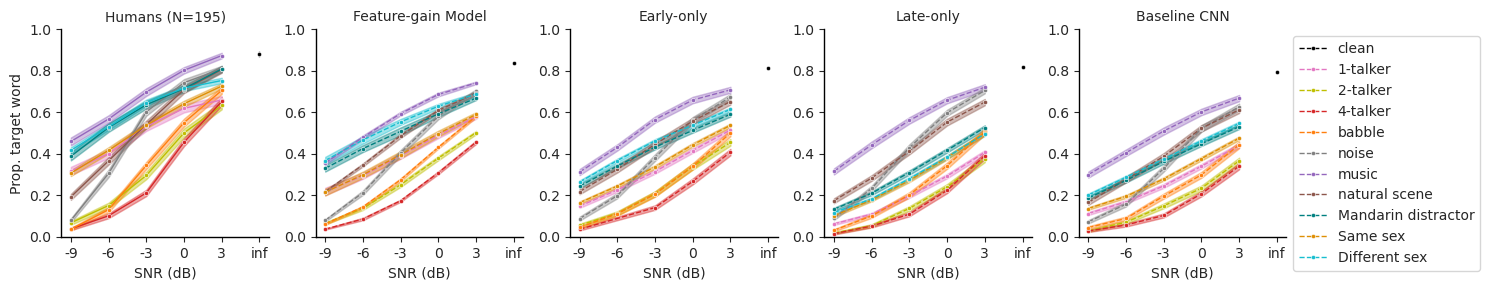

In [105]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = summary_results.copy() # & ~(combined_results.group == 'Baseline CNN')
sns.set_style('ticks')



# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker', '2-talker',  '4-talker', 'babble',  'noise',  'music', 'natural scene', 'Mandarin distractor', 'Same sex', "Different sex"]
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
palette['Mandarin distractor'] = 'teal'
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'


fontsize=10
tick_fontsize = 10
# fontsize = 10

# models = to_plot.group.unique()

models = ['Humans (N=195)', 'Feature-gain Model', 'Early-only', 'Late-only', 'Baseline CNN']

aspect = 3
n_models = len(models)
n_rows = n_models
n_cols = 1
sem_order = 1

fig, axs = plt.subplots(n_cols, n_rows, figsize=(aspect * n_rows, (aspect) * n_cols ))
axs = axs.flatten()

err_band_alpha = 0.4
# add markers to relplot
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=None,# err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['acc_sem'] = selected['acc_sem'] * sem_order
        # ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_sem", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['accuracy'] - selected['acc_sem'],
                         selected['accuracy'] + selected['acc_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
for ix in range(len(axs)):
    axs[ix].legend().remove()
    axs[ix].set_ylabel("", fontsize=fontsize)

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# set space between pannels 
# plt.subplots_adjust(wspace=0.25)
# 
plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_acc_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

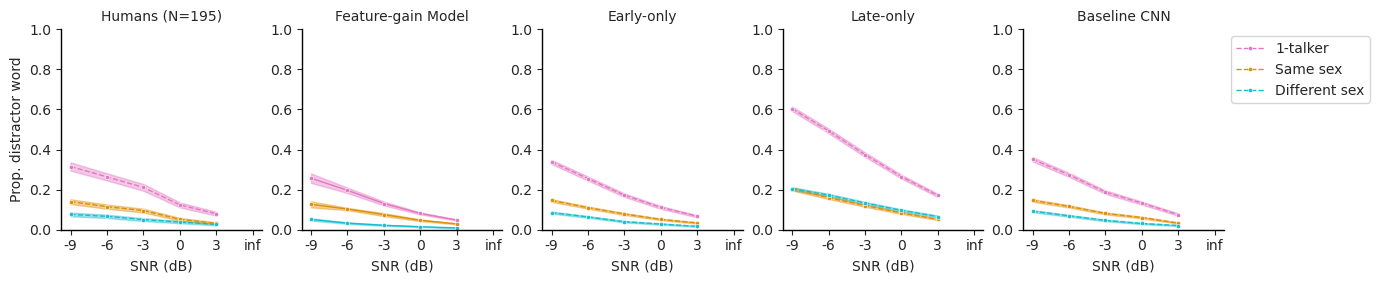

In [106]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = summary_results.copy() # & ~(combined_results.group == 'Baseline CNN')
sns.set_style('ticks')

hue_order = ['1-talker', 'Same sex', 'Different sex']
palette={}
palette['1-talker'] = 'tab:pink'
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

model_order = ['Humans (N=195)', 'Feature-gain Model', 'Early-only', 'Late-only', 'Baseline CNN']

aspect = 3
n_models = len(models)
n_rows = n_models
n_cols = 1
sem_order = 1

fig, axs = plt.subplots(n_cols, n_rows, figsize=(aspect * n_rows, (aspect) * n_cols ))
axs = axs.flatten()

err_band_alpha = 0.4
# add markers to relplot

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, model_order):
    ax.plot(x_tick_locs, np.ones(len(x_tick_locs)) * 0.5, 'w', alpha=0.5, label=None)

    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='confusions', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['conf_sem'] = selected['conf_sem'] * sem_order
        # ax.errorbar(data=selected, x="snr", y="confusions", yerr="conf_sem", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['confusions'] - selected['conf_sem'],
                         selected['confusions'] + selected['conf_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 

for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# set space between pannels 
# plt.subplots_adjust(wspace=0.25)

# plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_conf_english_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

In [42]:
model_results_to_save = res_for_scatter[~res_for_scatter.group.str.contains('Human')].groupby(['group', 'snr', 'background_condition']).agg({"adjusted_accuracy":['mean', 'sem'],"adjusted_confusions":['mean', 'sem', 'count'] }).reset_index()
model_results_to_save.columns =  ['group', 'snr', 'background_condition', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', "n_trials"]
model_results_to_save

,group,snr,background_condition,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,adj_conf_std_error,n_trials
0,Baseline CNN,-9,1-talker,0.111680,0.007131,0.351434,0.010809,1952
1,Baseline CNN,-9,2-talker,0.028689,0.005346,0.258197,0.014016,976
2,Baseline CNN,-9,4-talker,0.027664,0.005252,0.059426,0.007572,976
3,Baseline CNN,-9,Different sex,0.200820,0.007405,0.092555,0.005357,2928
4,Baseline CNN,-9,Dutch distractor,0.207480,0.009180,0.004098,0.001446,1952
...,...,...,...,...,...,...,...,...
717,word_task_v10_4MGB_ln_first_arch_9,3,babble,0.563525,0.015883,0.002049,0.001448,976
718,word_task_v10_4MGB_ln_first_arch_9,3,music,0.714139,0.014470,0.003074,0.001773,976
719,word_task_v10_4MGB_ln_first_arch_9,3,natural scene,0.669057,0.015070,0.001025,0.001025,976
720,word_task_v10_4MGB_ln_first_arch_9,3,noise,0.672131,0.015034,0.001025,0.001025,976


In [43]:
out_dir = Path("final_results_dir")
# human_results_to_save.to_pickle(out_dir / "summary_2024_SWC_diotic_participant_results.pdpkl")
# model_results_to_save.to_pickle(out_dir / "summary_2024_SWC_diotic_all_model_results.pdpkl")

## Make scatter plots 


#### Permutation test to determine p value 

### Permutation test for significance of fit to human accuracy

In [44]:
np.random.seed(0)

#### Bootstrap permutation test for r2 difference in  above plot.
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()
## Will construct null distribution differences in R2 between feature-gain model and baseline CNN via permutation test 
# we will do this by randomly permuting the model labels and recalculating the R2 for each bootstrap sample

n_boots = 10_000 

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
model_list = ['Feature-gain Model', 'Baseline CNN']
fontsize = 10

# human data is fixed
human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()

human_acc_values = human_df["adjusted_accuracy"].values

# get model data
actual_r2_values = []
for model in model_list:
    model_df = to_plot[to_plot.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    r, p = stats.pearsonr(human_acc_values,  model_df['adjusted_accuracy'].values)
    r2 = r**2
    actual_r2_values.append(r2)

actual_r2_diff = np.diff(actual_r2_values)[0]

# get bootstrap r2 diffs 
r2_diffs = np.zeros(n_boots)

model_results_df = to_plot.loc[to_plot.group.isin(model_list), ["snr", "background_condition", "adjusted_accuracy", "group"]].copy() # only take wanted columns for faster indexing 
model_group_list = model_results_df['group'].values
for n in tqdm(range(n_boots)):
    # permute for first group selection
    permuted_groups = np.random.permutation(model_group_list)
    group_a_ixs = np.argwhere(permuted_groups == model_list[0]).flatten()

    permuted_groups = np.random.permutation(model_group_list)
    group_b_ixs = np.argwhere(permuted_groups == model_list[1]).flatten()

    model_a_df = model_results_df.iloc[group_a_ixs]
    model_b_df = model_results_df.iloc[group_b_ixs]

    model_a_vals = model_a_df.groupby(['snr', 'background_condition']).adjusted_accuracy.mean().values
    model_b_vals = model_b_df.groupby(['snr', 'background_condition']).adjusted_accuracy.mean().values

    # get r2 values
    model_a_r, p = stats.pearsonr(human_acc_values, model_a_vals)
    model_a_r2 = model_a_r**2

    model_b_r, p = stats.pearsonr(human_acc_values,  model_b_vals)
    model_b_r2 = model_b_r**2
    
    r2_diffs[n] = model_a_r2 - model_b_r2


p_val = (np.abs(r2_diffs) > np.abs(actual_r2_diff)).mean()
threshold = 1/n_boots

print(f"Actual R2 diff: {actual_r2_diff:.3f}")
print(f"p-value: {p_val}")
print(f"Threshold: {threshold:.5f}")

ValueError: x and y must have the same length.

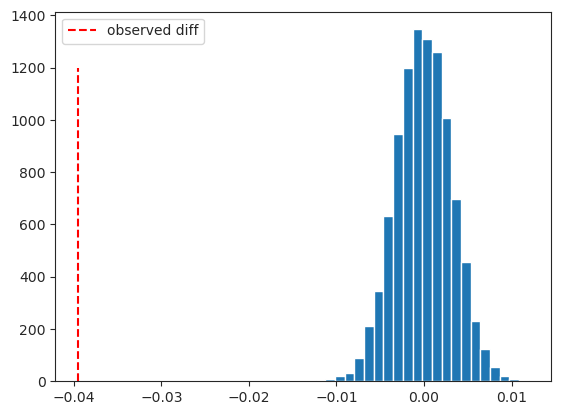

In [ ]:
plt.hist(r2_diffs,22)
plt.vlines(actual_r2_diff, 0, 1200, color='r', linestyle='--', label='observed diff')
plt.legend()

#### permutation test for confusions 

In [ ]:
np.random.seed(0)

#### Bootstrap permutation test for r2 difference in  above plot.
confusion_conditions = ['1-talker', "Same sex", "Different sex"]
# to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition.isin(confusion_conditions))]
to_plot = conf_results.copy() 

## Will construct null distribution differences in R2 between feature-gain model and baseline CNN via permutation test 
# we will do this by randomly permuting the model labels and recalculating the R2 for each bootstrap sample

n_boots = 10_000 

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
model_list = ['Feature-gain Model', 'Baseline CNN']
fontsize = 10

# human data is fixed
human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()

human_values = human_df["adjusted_confusions"].values

# get model data
actual_r2_values = []
for model in model_list:
    model_df = to_plot[to_plot.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({ 'adjusted_confusions':['mean']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'adjusted_confusions']
    r, p = stats.pearsonr(human_values,  model_df['adjusted_confusions'].values)
    r2 = r**2
    actual_r2_values.append(r2)

actual_r2_diff = np.diff(actual_r2_values)[0]

# get bootstrap r2 diffs 
r2_diffs = np.zeros(n_boots)

model_results_df = to_plot.loc[to_plot.group.isin(model_list), ["snr", "background_condition", "adjusted_confusions", "group"]].copy() # only take wanted columns for faster indexing 
model_group_list = model_results_df['group'].values
for n in tqdm(range(n_boots)):
    # permute for first group selection
    permuted_groups = np.random.permutation(model_group_list)
    group_a_ixs = np.argwhere(permuted_groups == model_list[0]).flatten()

    permuted_groups = np.random.permutation(model_group_list)
    group_b_ixs = np.argwhere(permuted_groups == model_list[1]).flatten()

    model_a_df = model_results_df.iloc[group_a_ixs]
    model_b_df = model_results_df.iloc[group_b_ixs]

    model_a_vals = model_a_df.groupby(['snr', 'background_condition']).adjusted_confusions.mean().values
    model_b_vals = model_b_df.groupby(['snr', 'background_condition']).adjusted_confusions.mean().values

    # get r2 values
    model_a_r, p = stats.pearsonr(human_values, model_a_vals)
    model_a_r2 = model_a_r**2

    model_b_r, p = stats.pearsonr(human_values,  model_b_vals)
    model_b_r2 = model_b_r**2
    
    r2_diffs[n] = model_a_r2 - model_b_r2


p_val = (np.abs(r2_diffs) > np.abs(actual_r2_diff)).mean()
threshold = 1/n_boots

print(f"Actual R2 diff: {actual_r2_diff:.3f}")
print(f"p-value: {p_val}")
print(f"Threshold: {threshold:.5f}")




100%|██████████| 10000/10000 [01:28<00:00, 112.97it/s]

Actual R2 diff: 0.024
p-value: 0.0132
Threshold: 0.00010


In [271]:
res_for_scatter.group.unique()

array(['Humans (N=195)', 'Baseline CNN', 'Early-only', 'Late-only',
       'Feature-gain Model', 'word_task_v10_4MGB_ln_first_arch_1',
       'word_task_v10_4MGB_ln_first_arch_10',
       'word_task_v10_4MGB_ln_first_arch_12',
       'word_task_v10_4MGB_ln_first_arch_2',
       'word_task_v10_4MGB_ln_first_arch_4',
       'word_task_v10_4MGB_ln_first_arch_6',
       'word_task_v10_4MGB_ln_first_arch_7',
       'word_task_v10_4MGB_ln_first_arch_8',
       'word_task_v10_4MGB_ln_first_arch_9'], dtype=object)

In [272]:
res_for_scatter

,snr,background_condition,accuracy,acc_std_error,confusions,conf_std_error,N,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,...,same_sex_distractor_1_transcripts,diff_sex_distractor_1_transcripts,same_sex_dist_1_word,diff_sex_dist_1_word,df_index,pred_word,true_word,sex_cond,dist_lang,index
0,-9,1-talker,0.239744,0.017325,0.150000,0.012397,195.0,0.317094,0.019581,0.315385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-9,2-talker,0.038462,0.007427,0.224786,0.014372,195.0,0.066667,0.009281,0.467949,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-9,4-talker,0.012821,0.003959,0.045299,0.007645,195.0,0.037607,0.006724,0.110684,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-9,Dutch distractor,0.266667,0.018001,0.000000,0.000000,195.0,0.379060,0.019822,0.002564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-9,Mandarin distractor,0.285043,0.018820,0.003846,0.002209,195.0,0.387607,0.020043,0.006410,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1145892,6,clean,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,385534.0
1145893,6,clean,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,385535.0
1145894,6,clean,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,385536.0
1145895,6,clean,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,385537.0


In [ ]:
# run same but per condition 
np.random.seed(0)

#### Bootstrap permutation test for r2 difference in  above plot.
confusion_conditions = ['1-talker', "Same sex", "Different sex"]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition.isin(confusion_conditions))]

## Will construct null distribution differences in R2 between feature-gain model and baseline CNN via permutation test 
# we will do this by randomly permuting the model labels and recalculating the R2 for each bootstrap sample

n_boots = 10_000 

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]
fontsize = 10

# human data is fixed
human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()

human_values = human_df["adjusted_confusions"].values
human_values_dict = {cond: human_df[human_df.background_condition == cond]["adjusted_confusions"].values for cond in confusion_conditions}

# get model data
actual_r2_values = {}
for model in model_list:
    actual_r2_values[model] = {}
    model_df = to_plot[to_plot.group == model]
    model_df = model_df.groupby(['snr', 'background_condition']).agg({ 'adjusted_confusions':['mean']}).reset_index()
    model_df.columns = ['snr', 'background_condition', 'adjusted_confusions']
    for cond in confusion_conditions:
        human_values = human_values_dict[cond]
        model_values = model_df[model_df.background_condition == cond].adjusted_confusions.values
        r, p = stats.pearsonr(human_values,  model_values)
        r2 = r**2
        actual_r2_values[model][cond] = r2

actual_r2_diffs = {cond: actual_r2_values['Feature-gain Model'][cond] - actual_r2_values['Baseline CNN'][cond] for cond in confusion_conditions}

# get bootstrap r2 diffs 

model_results_df = to_plot.loc[to_plot.group.isin(model_list), ["snr", "background_condition", "adjusted_confusions", "group"]].copy() # only take wanted columns for faster indexing 
model_group_list = model_results_df['group'].values

r2_cond_diffs = np.zeros((len(confusion_conditions), n_boots))

for n in tqdm(range(n_boots)):
    for j, cond in enumerate(confusion_conditions):
        # permute for first group selection
        permuted_groups = np.random.permutation(model_group_list)
        group_a_ixs = np.argwhere(permuted_groups == model_list[0]).flatten()

        permuted_groups = np.random.permutation(model_group_list)
        group_b_ixs = np.argwhere(permuted_groups == model_list[1]).flatten()

        model_a_df = model_results_df.iloc[group_a_ixs]
        model_b_df = model_results_df.iloc[group_b_ixs]

        # ix where condition is equal to cond
        model_a_df = model_a_df[model_a_df.background_condition == cond]
        model_b_df = model_b_df[model_b_df.background_condition == cond]


        model_a_vals = model_a_df.groupby(['snr']).adjusted_confusions.mean().values
        model_b_vals = model_b_df.groupby(['snr']).adjusted_confusions.mean().values

        # get r2 values
        model_a_r, p = stats.pearsonr(human_values, model_a_vals)
        model_a_r2 = model_a_r**2

        model_b_r, p = stats.pearsonr(human_values,  model_b_vals)
        model_b_r2 = model_b_r**2

        r2_cond_diffs[j, n] = model_a_r2 - model_b_r2



for ix, (cond, diffs) in enumerate(actual_r2_diffs.items()):
    p_val = (np.abs(r2_cond_diffs[ix]) > np.abs(diffs)).mean()
    threshold = 1/n_boots
    print('Condition:', cond)
    print(f"Actual R2 diff: {diffs:.3f}")
    print(f"p-value: {p_val}")
    print("\n")
print(f"Threshold: {threshold:.5f}")



100%|██████████| 10000/10000 [12:31<00:00, 13.31it/s]

Condition: 1-talker
Actual R2 diff: -0.027
p-value: 0.0096


Condition: Same sex
Actual R2 diff: -0.015
p-value: 0.2593


Condition: Different sex
Actual R2 diff: -0.045
p-value: 0.0427


Threshold: 0.00010


#### The scatter plot

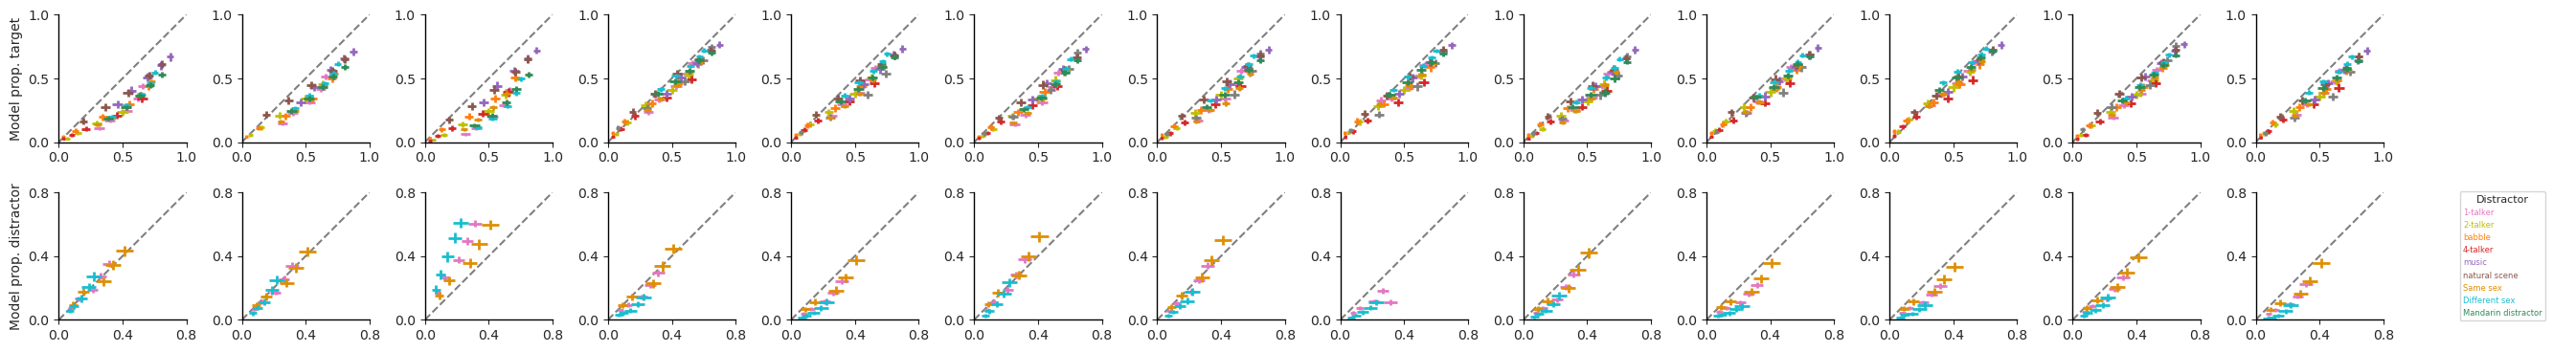

In [46]:
# to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()


# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex',  'Mandarin distractor', 'noise', 'music', 'natural scene', 'Different sex',]

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'


hue_order = list(palette.keys())

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]

fontsize = 10

aspect = 2
fig, axs = plt.subplots(2, 1 + len(model_list), figsize=((aspect * len(model_list) + 1 ) , aspect*2 ))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_acc_means_full = human_df["adjusted_accuracy"].values
# get confusion data
confusion_conditions = ['1-talker', 'Same sex', "Different sex"]
human_conf_df = conf_results[conf_results.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_conf_means_full = human_conf_df.adjusted_confusions.values

for ix, model in enumerate(model_list):

    model_df = to_plot[to_plot.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_df.sort_values(['snr', 'background_condition'], inplace=True)   
    for condition in hue_order:
        try:
        # plot acc 
            human_data = human_df[human_df.background_condition == condition]
            human_means = human_data["adjusted_accuracy"].values
            human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

            model_data = model_df[model_df.background_condition == condition]
            model_means = model_data["adjusted_accuracy"].values
            model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

            acc_axs[ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='',
                            linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])#, mfc=palette[condition], mec=palette[condition])
        except:
            continue
    model_conf_df = conf_results[conf_results.group == model]
    model_conf_df = model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)
    # model confusions
    for condition in confusion_conditions:
        try:
            human_conf_data = human_conf_df[human_conf_df.background_condition == condition]
            human_conf_means = human_conf_data["adjusted_confusions"].values
            human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI
                
            model_conf_data = model_conf_df[model_conf_df.background_condition ==  condition]
            model_conf_means = model_conf_data["adjusted_confusions"].values
            model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

            conf_axs[ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='',
                                linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])
        except:
            continue
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    try:
        r, p = stats.pearsonr(human_acc_means_full,  model_df['adjusted_accuracy'].values)
        # spearman_brown_r = r / np.sqrt(human_rho_acc)
        acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.85), fontsize=fontsize)

        # samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - model_df['accuracy'].values)**2))
        # acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

        # conf errors
        # res = stats.spearmanr(human_conf_means, model_conf_means)
        # rho = res.statistic
        # conf_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
        model_conf_values = model_conf_df['adjusted_confusions'].values
        r, p = stats.pearsonr(human_conf_means_full, model_conf_values)
        # spearman_brown_r = r / np.sqrt(human_rho_conf)
        conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.25, 0.025), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    except:
        continue
    # samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    # conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.3, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    acc_axs[ix].set_title(model, fontsize=fontsize)
    conf_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# # move axs[1] to left 

# pos = acc_axs[1].get_position()
# pos.x0 -= 0.025
# acc_axs[1].set_position(pos)

# # move axs[3] to left 
# pos = conf_axs[1].get_position()
# pos.x0 -= 0.025
# conf_axs[1].set_position(pos)

## add legend 
handles, labels = axs[0,0].get_legend_handles_labels()

axs[0,-1].axis('off')
axs[1,-1].axis('off')
legend = axs[1, -1].legend([axs[1, -1].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')

for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
axs[0, -1].set_box_aspect(1)

plt.tight_layout()
# plt.savefig(outfig_dest/'human_model_var_exp_scatters.pdf', transparent=True, bbox_inches='tight')
# 

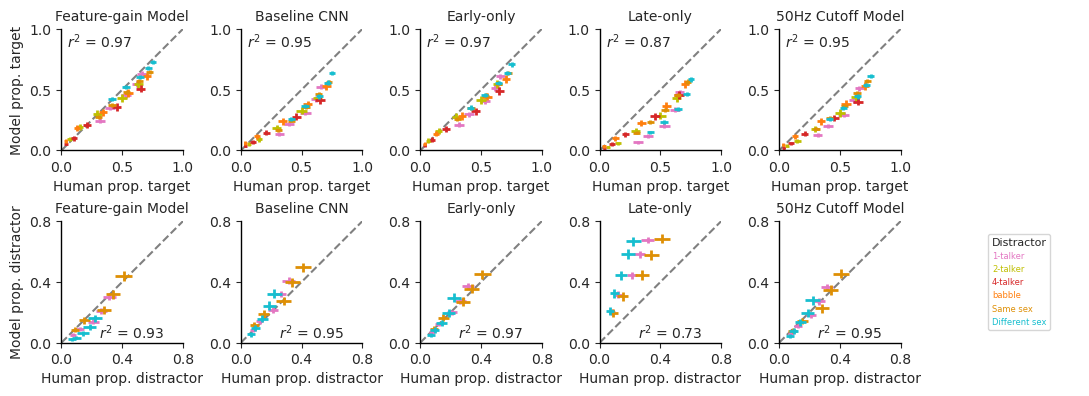

In [ ]:
## Speech only conditions 
# to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()


# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = [ '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex',  'Different sex',]

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'


# hue_order = list(palette.keys())

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]

fontsize = 10

aspect = 2
fig, axs = plt.subplots(2, 1 + len(model_list), figsize=((aspect * len(model_list) + 1 ) , aspect*2 ))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_df = human_df[human_df.background_condition.isin(hue_order)]  

human_acc_means_full = human_df["adjusted_accuracy"].values
# get confusion data
confusion_conditions = ['1-talker', 'Same sex', "Different sex"]
human_conf_df = conf_results[conf_results.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_conf_df = human_conf_df[human_conf_df.background_condition.isin(confusion_conditions)]
human_conf_means_full = human_conf_df.adjusted_confusions.values

for ix, model in enumerate(model_list):

    model_df = to_plot[(to_plot.group == model) & (to_plot.background_condition.isin(hue_order))]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_df.sort_values(['snr', 'background_condition'], inplace=True)   
    for condition in hue_order:
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        acc_axs[ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])

    model_conf_df = conf_results[(conf_results.group == model) & (conf_results.background_condition.isin(confusion_conditions))]
    model_conf_df = model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)
    # model confusions
    for condition in confusion_conditions:
        try:
            human_conf_data = human_conf_df[human_conf_df.background_condition == condition]
            human_conf_means = human_conf_data["adjusted_confusions"].values
            human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI
                
            model_conf_data = model_conf_df[model_conf_df.background_condition ==  condition]
            model_conf_means = model_conf_data["adjusted_confusions"].values
            model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

            conf_axs[ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='',
                                linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])
        except:
            continue
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    try:
        r, p = stats.pearsonr(human_acc_means_full,  model_df['adjusted_accuracy'].values)
        # spearman_brown_r = r / np.sqrt(human_rho_acc)
        acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.85), fontsize=fontsize)

        # samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - model_df['accuracy'].values)**2))
        # acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

        # conf errors
        # res = stats.spearmanr(human_conf_means, model_conf_means)
        # rho = res.statistic
        # conf_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
        model_conf_values = model_conf_df['adjusted_confusions'].values
        r, p = stats.pearsonr(human_conf_means_full, model_conf_values)
        # spearman_brown_r = r / np.sqrt(human_rho_conf)
        conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.25, 0.025), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    except:
        continue
    # samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    # conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.3, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    acc_axs[ix].set_title(model, fontsize=fontsize)
    conf_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# # move axs[1] to left 

# pos = acc_axs[1].get_position()
# pos.x0 -= 0.025
# acc_axs[1].set_position(pos)

# # move axs[3] to left 
# pos = conf_axs[1].get_position()
# pos.x0 -= 0.025
# conf_axs[1].set_position(pos)

## add legend 
handles, labels = axs[0,0].get_legend_handles_labels()

axs[0,-1].axis('off')
axs[1,-1].axis('off')
legend = axs[1, -1].legend([axs[1, -1].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')

for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
axs[0, -1].set_box_aspect(1)

plt.tight_layout()
# plt.savefig(outfig_dest/'human_model_var_exp_scatters.pdf', transparent=True, bbox_inches='tight')
# 

## Compare alternative models to main model




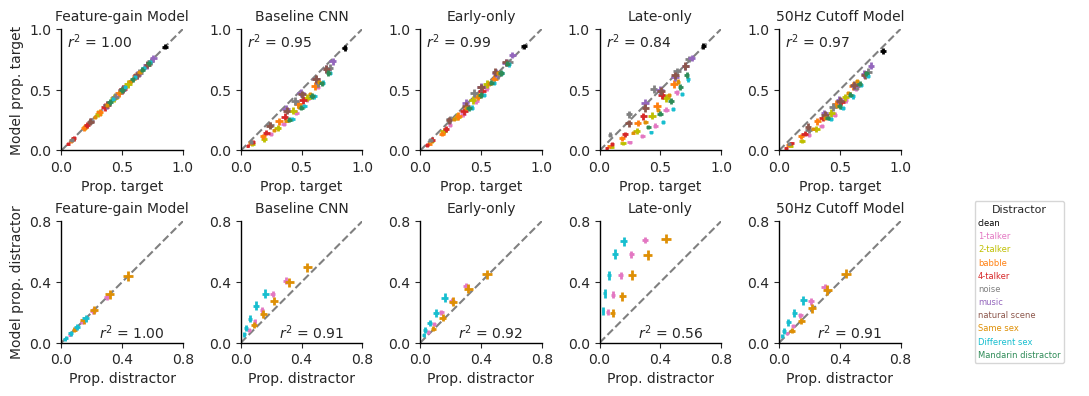

In [ ]:
# to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()


# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex',  'Mandarin distractor', 'noise', 'music', 'natural scene', 'Different sex',]

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'


hue_order = list(palette.keys())

x = y = np.linspace(0,1,5)

main_model_str = f"Feature-gain Model"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]

fontsize = 10

aspect = 2
fig, axs = plt.subplots(2, 1 + len(model_list), figsize=((aspect * len(model_list) + 1 ) , aspect*2 ))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='grey')

main_model_df = to_plot[to_plot.group == main_model_str].sort_values(['snr', 'background_condition']).copy()
main_model_df = main_model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                    'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
main_model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
main_model_df.sort_values(['snr', 'background_condition'], inplace=True) 
main_model_acc_means_full = main_model_df["adjusted_accuracy"].values
# get confusion data
confusion_conditions = ['1-talker', 'Same sex', "Different sex"]
main_model_conf_df = conf_results[conf_results.group == main_model_str].copy()
main_model_conf_df = main_model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
main_model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
main_model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)

main_model_conf_means_full = main_model_conf_df.adjusted_confusions.values

for ix, model in enumerate(model_list):

    model_df = to_plot[to_plot.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_df.sort_values(['snr', 'background_condition'], inplace=True)   
    for condition in hue_order:
        # plot acc 
        main_model_data = main_model_df[main_model_df.background_condition == condition]
        main_model_means = main_model_data["adjusted_accuracy"].values
        main_model_errors = main_model_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        acc_axs[ix].errorbar(x=main_model_means, y=model_means, xerr=main_model_errors, yerr=model_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])

    model_conf_df = conf_results[conf_results.group == model]
    model_conf_df = model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)
    # model confusions
    for condition in confusion_conditions:
        try:
            main_model_conf_data = main_model_conf_df[main_model_conf_df.background_condition == condition]
            main_model_conf_means = main_model_conf_data["adjusted_confusions"].values
            main_model_conf_errors = main_model_conf_data["adj_conf_std_error"].values * 2 # 95% CI
                
            model_conf_data = model_conf_df[model_conf_df.background_condition ==  condition]
            model_conf_means = model_conf_data["adjusted_confusions"].values
            model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

            conf_axs[ix].errorbar(x=main_model_conf_means, y=model_conf_means, xerr=main_model_conf_errors, yerr=model_conf_errors, marker='',
                                linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])
        except:
            continue
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(main_model_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    try:
        r, p = stats.pearsonr(main_model_acc_means_full,  model_df['adjusted_accuracy'].values)
        # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
        acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.85), fontsize=fontsize)

        # samp_rmse = np.sqrt(np.mean((main_model_df["accuracy"].values - model_df['accuracy'].values)**2))
        # acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

        # conf errors
        # res = stats.spearmanr(main_model_conf_means, model_conf_means)
        # rho = res.statistic
        # conf_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
        model_conf_values = model_conf_df['adjusted_confusions'].values
        r, p = stats.pearsonr(main_model_conf_means_full, model_conf_values)
        # spearman_brown_r = r / np.sqrt(main_model_rho_conf)
        conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.25, 0.025), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    except:
        continue
    # samp_rmse = np.sqrt(np.mean((main_model_conf_means - model_conf_means)**2))
    # conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.3, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    acc_axs[ix].set_title(model, fontsize=fontsize)
    conf_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# # move axs[1] to left 

# pos = acc_axs[1].get_position()
# pos.x0 -= 0.025
# acc_axs[1].set_position(pos)

# # move axs[3] to left 
# pos = conf_axs[1].get_position()
# pos.x0 -= 0.025
# conf_axs[1].set_position(pos)

## add legend 
handles, labels = axs[0,0].get_legend_handles_labels()

axs[0,-1].axis('off')
axs[1,-1].axis('off')
legend = axs[1, -1].legend([axs[1, -1].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')

for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
axs[0, -1].set_box_aspect(1)

plt.tight_layout()
# plt.savefig(outfig_dest/'main_model_model_var_exp_scatters.pdf', transparent=True, bbox_inches='tight')
# 

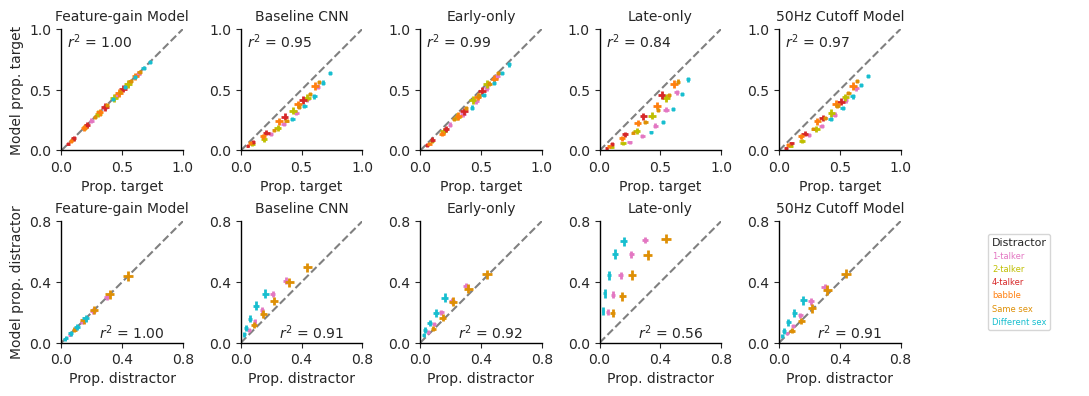

In [ ]:
# to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()


# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = [ '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex', 'Different sex',]

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'


# hue_order = list(palette.keys())

x = y = np.linspace(0,1,5)

main_model_str = f"Feature-gain Model"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]

fontsize = 10

aspect = 2
fig, axs = plt.subplots(2, 1 + len(model_list), figsize=((aspect * len(model_list) + 1 ) , aspect*2 ))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='grey')

main_model_df = to_plot[to_plot.group == main_model_str].sort_values(['snr', 'background_condition']).copy()
main_model_df = main_model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                    'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
main_model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
main_model_df.sort_values(['snr', 'background_condition'], inplace=True) 
main_model_acc_means_full = main_model_df["adjusted_accuracy"].values
# get confusion data
confusion_conditions = ['1-talker', 'Same sex', "Different sex"]
main_model_conf_df = conf_results[conf_results.group == main_model_str].copy()
main_model_conf_df = main_model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
main_model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
main_model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)

main_model_conf_means_full = main_model_conf_df.adjusted_confusions.values

for ix, model in enumerate(model_list):

    model_df = to_plot[to_plot.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_df.sort_values(['snr', 'background_condition'], inplace=True)   
    for condition in hue_order:
        # plot acc 
        main_model_data = main_model_df[main_model_df.background_condition == condition]
        main_model_means = main_model_data["adjusted_accuracy"].values
        main_model_errors = main_model_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        acc_axs[ix].errorbar(x=main_model_means, y=model_means, xerr=main_model_errors, yerr=model_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])

    model_conf_df = conf_results[conf_results.group == model]
    model_conf_df = model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)
    # model confusions
    for condition in confusion_conditions:
        try:
            main_model_conf_data = main_model_conf_df[main_model_conf_df.background_condition == condition]
            main_model_conf_means = main_model_conf_data["adjusted_confusions"].values
            main_model_conf_errors = main_model_conf_data["adj_conf_std_error"].values * 2 # 95% CI
                
            model_conf_data = model_conf_df[model_conf_df.background_condition ==  condition]
            model_conf_means = model_conf_data["adjusted_confusions"].values
            model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

            conf_axs[ix].errorbar(x=main_model_conf_means, y=model_conf_means, xerr=main_model_conf_errors, yerr=model_conf_errors, marker='',
                                linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])
        except:
            continue
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(main_model_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    try:
        r, p = stats.pearsonr(main_model_acc_means_full,  model_df['adjusted_accuracy'].values)
        # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
        acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.85), fontsize=fontsize)

        # samp_rmse = np.sqrt(np.mean((main_model_df["accuracy"].values - model_df['accuracy'].values)**2))
        # acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

        # conf errors
        # res = stats.spearmanr(main_model_conf_means, model_conf_means)
        # rho = res.statistic
        # conf_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
        model_conf_values = model_conf_df['adjusted_confusions'].values
        r, p = stats.pearsonr(main_model_conf_means_full, model_conf_values)
        # spearman_brown_r = r / np.sqrt(main_model_rho_conf)
        conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.25, 0.025), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    except:
        continue
    # samp_rmse = np.sqrt(np.mean((main_model_conf_means - model_conf_means)**2))
    # conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.3, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    acc_axs[ix].set_title(model, fontsize=fontsize)
    conf_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# # move axs[1] to left 

# pos = acc_axs[1].get_position()
# pos.x0 -= 0.025
# acc_axs[1].set_position(pos)

# # move axs[3] to left 
# pos = conf_axs[1].get_position()
# pos.x0 -= 0.025
# conf_axs[1].set_position(pos)

## add legend 
handles, labels = axs[0,0].get_legend_handles_labels()

axs[0,-1].axis('off')
axs[1,-1].axis('off')
legend = axs[1, -1].legend([axs[1, -1].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')

for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
axs[0, -1].set_box_aspect(1)

plt.tight_layout()
# plt.savefig(outfig_dest/'main_model_model_var_exp_scatters.pdf', transparent=True, bbox_inches='tight')
# 

___
## Manually compute and plot confidence intervals per model

KeyboardInterrupt: 

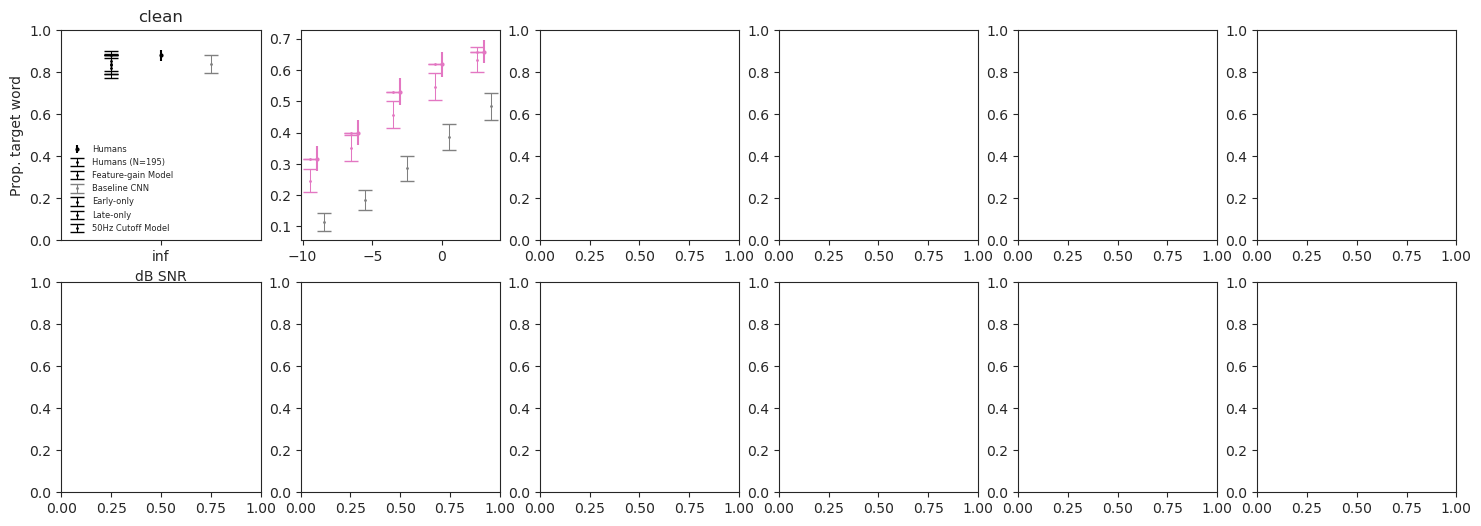

In [ ]:

### make significance plots 

## What we want: for each model for each background condition, compute confidence intervals. Then, see if human data falls within the confidence intervals.
# 1. For each model, for each background condition, compute the mean and standard error of the mean for adjusted accuracy and adjusted confusions.
# 2. For each model, for each background condition, compute the confidence intervals for adjusted accuracy and adjusted confusions.
# 3. For each model, for each background condition, check if the human data falls within the confidence intervals for adjusted accuracy and adjusted confusions.
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex', 'Different sex', 'Mandarin distractor', 'noise', 'music', 'natural scene']

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'



n_conditions = len(hue_order)
n_rows = 2 
n_cols = n_conditions // n_rows +1
pannel_width = 3
pannel_height = 3
# plot will be accuracy by snr for each condition in hue_order 
fig, axs = plt.subplots(n_rows, n_cols, figsize=(pannel_width * n_cols, pannel_height * n_rows))
axs = axs.flatten()

n_boots = 1000 

x_dodge_factor = 0.5

# get human data
human_data = to_plot[to_plot.group == human_str]
# get human confusion data
human_conf_data = human_data[human_data.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI


for ix, condition in enumerate(hue_order):
    # get human data
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["adjusted_accuracy"].values
    human_errors = human_data["adj_acc_std_error"].values * 2

    # get snrs per condition 
    snrs = human_data.snr.unique()
    x_ticks = np.array([snr for snr in snrs])
    x_tick_labels = [str(x) for x in snrs]
    x_tick_labels[-1] = 'inf'
    n_snrs = len(snrs)
    
     ## plot model vs human data
    if condition == 'clean':
        x_ticks = np.array([0]) # set to 0 for clean condition
    axs[ix].errorbar(x_ticks, human_means, yerr=human_errors, xerr=None, fmt='o', color=palette[condition], label='Humans',
                        markersize=2)
    for model in model_list:
        model_df = to_plot[to_plot.group == model]

        # get model data to bootstrap confidence intervals per snr 
        model_bootstrap_means = np.zeros((n_snrs, n_boots))
        model_data = model_df[model_df.background_condition == condition]

        # bootstrap model means
        for snr_ix, snr in enumerate(snrs):
            for n in range(n_boots):
                vals = model_data[model_data.snr == snr].adjusted_accuracy.values
                sample = np.random.choice(vals, size=len(vals), replace=True)
                model_bootstrap_means[snr_ix, n] = sample.mean()

        # get confidence intervals from bootstraped means per snr 
        conf_ints = np.percentile(model_bootstrap_means, [2.5, 97.5], axis=1)
        conf_int_sizes = np.ptp(conf_ints, axis=0) # get max - min for error bars
        model_means = model_bootstrap_means.mean(axis=1)

   
        dodge = x_dodge_factor * 1 if model == 'Baseline CNN' else x_dodge_factor * -1
        model_color = 'grey' if model == 'Baseline CNN' else  palette[condition]
        axs[ix].errorbar(x_ticks + dodge, model_means, yerr=conf_int_sizes, xerr=None, fmt='.',
                            color=model_color, label=model, capsize=5, elinewidth=0.75,  markersize=2)
    axs[ix].set_title(condition)
    axs[ix].set_xticks(ticks=x_ticks) # set new labels
    axs[ix].set_xticklabels(labels=x_tick_labels,fontsize=fontsize) 
    if condition == 'clean':
        axs[ix].set_xlim(-1,1)
    # axs[ix].set_yticks(ticks=ticks) # set new labels
    # axs[ix].set_yticklabels(labels= ticks, fontsize=fontsize)
    axs[ix].set_ylim(0,1)
    if ix == 0 or ix == 5:
        axs[ix].set_ylabel("Prop. target word")
    axs[ix].set_xlabel("dB SNR")
    axs[ix].legend(fontsize=fontsize-4, frameon=False, loc='best')


# increase vertical space 
plt.subplots_adjust(hspace=0.5)
ratio = 1.0
for ax in axs:
    # set square ratio 
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)


In [ ]:

### make significance plots 

## What we want: for each model for each background condition, compute confidence intervals. Then, see if human data falls within the confidence intervals.
# 1. For each model, for each background condition, compute the mean and standard error of the mean for adjusted accuracy and adjusted confusions.
# 2. For each model, for each background condition, compute the confidence intervals for adjusted accuracy and adjusted confusions.
# 3. For each model, for each background condition, check if the human data falls within the confidence intervals for adjusted accuracy and adjusted confusions.
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']

# get human data
human_data = to_plot[to_plot.group == human_str]
# get human confusion data
human_conf_data = human_data[human_data.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI

model_diff_dict = {}
for ix, condition in enumerate(hue_order):
    model_diff_dict[condition] = {}
    # get human data
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["adjusted_accuracy"].values
    human_errors = human_data["adj_acc_std_error"].values * 2

    # get snrs per condition 
    snrs = human_data.snr.unique()
    # x_ticks = np.array([snr for snr in snrs])
    # x_tick_labels = [str(x) for x in snrs]
    n_snrs = len(snrs)
    
    for model in model_list:
        model_df = to_plot[to_plot.group == model]

        # get model data to bootstrap confidence intervals per snr 
        bootstrap_diffs = np.empty((n_snrs, n_boots))
        model_data = model_df[model_df.background_condition == condition]

        # bootstrap model means
        for n in range(n_boots):
            sample = model_data.groupby('snr').adjusted_accuracy.apply(lambda x: x.sample(frac=1, replace=True)).groupby('snr').mean().values
            diff = np.abs(sample - human_means)
            bootstrap_diffs[:, n] = diff
        model_diff_dict[condition][model] = bootstrap_diffs
    


In [ ]:
    
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'tab:green'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# palette['Mandarin distractor'] = 'teal'
## add language distractors 
cmap = sns.color_palette("gnuplot2", n_colors=3)
palette['Mandarin distractor'] =  cmap[0]
palette['Dutch distractor'] =  cmap[2]


n_conditions = len(hue_order)
n_rows = 2 
n_cols = n_conditions // n_rows
pannel_width = 3
pannel_height = 3
# plot will be accuracy by snr for each condition in hue_order 
# fig, axs = plt.subplots(n_rows, n_cols, figsize=(pannel_width * n_cols, pannel_height * n_rows))
fig, axs = plt.subplots(1, 1, figsize=(6,3))

# axs = axs.flatten()

x_ticks = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_ticks]
x_tick_labels[-1] = 'inf'


y_ticks = np.arange(len(hue_order))
y_tick_labels = hue_order


n_boots = 1000 

x_dodge_factor = 0.5

for ix, condition in enumerate(hue_order):
    # get human data
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["adjusted_accuracy"].values
    human_errors = human_data["adj_acc_std_error"].values * 2

    # get snrs per condition 
    snrs = human_data.snr.unique()
    # x_ticks = np.array([snr for snr in snrs])
    # x_tick_labels = [str(x) for x in snrs]
    n_snrs = len(snrs)
    
    gain_model_diffs = model_diff_dict[condition]['Feature-gain Model']
    baseline_diffs = model_diff_dict[condition]['Baseline CNN']
    p_vals = stats.ttest_ind(gain_model_diffs, baseline_diffs, alternative='less', axis=1).pvalue
    print(p_vals, ix)

    y_vals = np.zeros(n_snrs)
    y_vals[:] = np.nan

    y_vals[p_vals < 0.001] = ix + 1 
    # p_within_threshold = (bootstrap_diffs <= 0.025 ).mean(axis=1)
    
    # dodge = x_dodge_factor * 1 if model == 'Baseline CNN' else x_dodge_factor * -1
    # model_color = 'grey' if model == 'Baseline CNN' else  palette[condition]
    color = palette[condition]
    axs.plot(snrs, y_vals,  color=color, label=condition)
    # axs.set_title(condition)

axs.set_xticks(ticks=x_ticks) # set new labels
axs.set_xticklabels(labels=x_tick_labels,fontsize=fontsize) 
# axs.set_yticks(ticks=y_ticks+1) # set new labels
# axs.set_yticklabels(labels=y_tick_labels, fontsize=fontsize)



    # axs.set_yticks(ticks=ticks) # set new labels
    # axs.set_ylim(0,1)
    # if ix == 0 or ix == 5:
        # axs.set_ylabel("p-value")
axs.set_xlabel("dB SNR")

    # axs.legend(fontsize=fontsize-4, frameon=False, loc='best')


# increase vertical space 
# plt.subplots_adjust(hspace=0.5)
# # ratio = 1.0
# for ax in axs:
#     # set square ratio 
#     xleft, xright = ax.get_xlim()
#     ybottom, ytop = ax.get_ylim()
#     ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
